# Search Query Correlation with 80-Year Threshold Leases

This notebook analyzes the correlation between search queries (view counts) and properties with leases approaching the 80-year threshold.

## Overview

- **Data Sources**: `leaseviewstats` (search statistics) and `leasesext` (lease data)
- **Analysis**: Correlation between view counts and remaining lease years near 80-year threshold
- **Output**: Correlation statistics, scatter plots, and trend analysis

---
## 1. Setup and Imports

First, we import all necessary libraries and configure our environment.

In [1]:
import os
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pymongo import MongoClient
from tqdm.notebook import tqdm

print("✓ All imports completed successfully!")


✓ All imports completed successfully!


---
## 2. Configuration

Load connection details from the `.env` file and set up paths.

In [2]:
env_path = Path("../.env")
load_dotenv(env_path)

MONGO_URI = os.getenv("MONGO_URI_NOTEBOOK")
MONGO_DATABASE = os.getenv("MONGO_DATABASE")

TODAY = datetime(2026, 3, 10)
THRESHOLD_YEARS = 80
APPROACHING_RANGE = 10  # Leases between 70-90 years are "approaching" threshold

print(f"Database: {MONGO_DATABASE}")
print(f"Today's date: {TODAY.strftime('%B %d, %Y')}")
print(f"Threshold: {THRESHOLD_YEARS} years")
print(f"Approaching range: {THRESHOLD_YEARS - APPROACHING_RANGE} to {THRESHOLD_YEARS + APPROACHING_RANGE} years")


Database: leases
Today's date: March 10, 2026
Threshold: 80 years
Approaching range: 70 to 90 years


---
## 3. Connect to MongoDB

Establish a connection to the local MongoDB instance and verify the collection exists.

In [3]:
client = MongoClient(MONGO_URI)
db = client[MONGO_DATABASE]
collection_ext = db["leasesext"]
collection_views = db["leaseviewstats"]

print(f"✓ Connected to MongoDB successfully!")
print(f"leaseviewstats count: {collection_views.count_documents({}):,}")
print(f"leasesext count: {collection_ext.count_documents({}):,}")


✓ Connected to MongoDB successfully!
leaseviewstats count: 18,407
leasesext count: 6,718,668


---
## 4. Fetch View Statistics

Fetch and prepare view statistics

In [4]:
print("Fetching view statistics...")
view_stats = list(collection_views.find({}, {"uniqueId": 1, "viewCount": 1}))
print(f"Found {len(view_stats):,} view records")

# Create lookup dictionary
uid_to_views = {v['uniqueId']: v['viewCount'] for v in view_stats}
uids_with_views = list(uid_to_views.keys())
print(f"Unique lease IDs with views: {len(uids_with_views):,}")

Fetching view statistics...
Found 18,407 view records
Unique lease IDs with views: 18,407


---
## 5. Helper Functions

Define functions for date processing

In [5]:
def calculate_years_remaining(expiry_date):
    """Calculate years remaining from today to expiry date."""
    if expiry_date is None:
        return None
    return (expiry_date - TODAY).days / 365.25


---
## 6. Process View Stats

Query Leases with View Data

In [6]:
BATCH_SIZE = 10000
lease_data = []

print("Processing leases with view data...")

for i in tqdm(range(0, len(uids_with_views), BATCH_SIZE), desc="Batch processing"):
    batch_uids = uids_with_views[i:i + BATCH_SIZE]
    
    query = {
        "uid": {"$in": batch_uids},
        "exp": {"$exists": True, "$ne": None}
    }
    
    cursor = collection_ext.find(query, {"uid": 1, "exp": 1})
    
    for doc in cursor:
        uid = doc['uid']
        exp = doc['exp']
        
        years_remaining = calculate_years_remaining(exp)
        if years_remaining is None:
            continue
        
        view_count = uid_to_views.get(uid, 0)
        
        lease_data.append({
            'uid': uid,
            'years_remaining': years_remaining,
            'view_count': view_count
        })

print(f"\n✓ Processed {len(lease_data):,} leases with valid expiry and view data")


Processing leases with view data...


Batch processing:   0%|          | 0/2 [00:00<?, ?it/s]


✓ Processed 23,494 leases with valid expiry and view data


---
## 7. Categorize Short Leases

Create DataFrame and categorize short leases

In [7]:
df = pd.DataFrame(lease_data)

# Categorize leases
def categorize_lease(years):
    if years < 70:
        return 'Critical (<70 years)'
    elif years < 80:
        return 'Approaching (70-80 years)'
    elif years < 90:
        return 'Near threshold (80-90 years)'
    elif years < 100:
        return 'Moderate (90-100 years)'
    else:
        return 'Long (100+ years)'

df['category'] = df['years_remaining'].apply(categorize_lease)

# Add binary flag for approaching threshold
df['approaching_threshold'] = (df['years_remaining'] >= 70) & (df['years_remaining'] < 90)

print(f"DataFrame shape: {df.shape}")
print(f"\nCategory distribution:")
print(df['category'].value_counts())


DataFrame shape: (23494, 5)

Category distribution:
category
Long (100+ years)               13081
Near threshold (80-90 years)     4506
Critical (<70 years)             3460
Moderate (90-100 years)          1414
Approaching (70-80 years)        1033
Name: count, dtype: int64


In [8]:
# Summary Statistics by Category
print("=" * 80)
print("VIEW COUNT STATISTICS BY LEASE CATEGORY")
print("=" * 80)

summary = df.groupby('category')['view_count'].agg(['count', 'sum', 'mean', 'median', 'std'])
summary = summary.round(2)
print(summary.to_string())

print(f"\nOverall statistics:")
print(f"  Total leases: {len(df):,}")
print(f"  Total views: {df['view_count'].sum():,}")
print(f"  Mean views per lease: {df['view_count'].mean():.2f}")
print(f"  Median views per lease: {df['view_count'].median():.2f}")


VIEW COUNT STATISTICS BY LEASE CATEGORY
                              count    sum  mean  median   std
category                                                      
Approaching (70-80 years)      1033   1371  1.33     1.0  0.88
Critical (<70 years)           3460   4593  1.33     1.0  2.31
Long (100+ years)             13081  16430  1.26     1.0  1.08
Moderate (90-100 years)        1414   1718  1.21     1.0  0.69
Near threshold (80-90 years)   4506   5855  1.30     1.0  1.05

Overall statistics:
  Total leases: 23,494
  Total views: 29,967
  Mean views per lease: 1.28
  Median views per lease: 1.00


---
## 8. Correlation Analysis

Analyse correlation between years remaining and view count

In [9]:
# Cell 10 - Correlation Analysis
print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Overall correlation
pearson_corr, pearson_p = stats.pearsonr(df['years_remaining'], df['view_count'])
spearman_corr, spearman_p = stats.spearmanr(df['years_remaining'], df['view_count'])

print(f"\nOverall correlation between years remaining and view count:")
print(f"  Pearson correlation:  r = {pearson_corr:.4f}, p-value = {pearson_p:.4e}")
print(f"  Spearman correlation: ρ = {spearman_corr:.4f}, p-value = {spearman_p:.4e}")

# Focus on leases near the 80-year threshold (60-100 years)
df_near_threshold = df[(df['years_remaining'] >= 60) & (df['years_remaining'] <= 100)]

if len(df_near_threshold) > 2:
    pearson_near, p_near = stats.pearsonr(df_near_threshold['years_remaining'], df_near_threshold['view_count'])
    spearman_near, sp_near = stats.spearmanr(df_near_threshold['years_remaining'], df_near_threshold['view_count'])
    
    print(f"\nCorrelation for leases near threshold (60-100 years):")
    print(f"  Sample size: {len(df_near_threshold):,}")
    print(f"  Pearson correlation:  r = {pearson_near:.4f}, p-value = {p_near:.4e}")
    print(f"  Spearman correlation: ρ = {spearman_near:.4f}, p-value = {sp_near:.4e}")


CORRELATION ANALYSIS

Overall correlation between years remaining and view count:
  Pearson correlation:  r = -0.0201, p-value = 2.0194e-03
  Spearman correlation: ρ = -0.0271, p-value = 3.1588e-05

Correlation for leases near threshold (60-100 years):
  Sample size: 7,890
  Pearson correlation:  r = -0.0058, p-value = 6.0762e-01
  Spearman correlation: ρ = -0.0218, p-value = 5.2562e-02


In [10]:
# T-test: Approaching vs Not Approaching Threshold
print("=" * 80)
print("T-TEST: APPROACHING THRESHOLD vs OTHER LEASES")
print("=" * 80)

approaching = df[df['approaching_threshold']]['view_count']
not_approaching = df[~df['approaching_threshold']]['view_count']

t_stat, t_pvalue = stats.ttest_ind(approaching, not_approaching)
mann_whitney, mw_pvalue = stats.mannwhitneyu(approaching, not_approaching, alternative='two-sided')

print(f"\nApproaching threshold (70-90 years):")
print(f"  Count: {len(approaching):,}")
print(f"  Mean views: {approaching.mean():.2f}")
print(f"  Median views: {approaching.median():.2f}")

print(f"\nOther leases:")
print(f"  Count: {len(not_approaching):,}")
print(f"  Mean views: {not_approaching.mean():.2f}")
print(f"  Median views: {not_approaching.median():.2f}")

print(f"\nStatistical tests:")
print(f"  T-test: t = {t_stat:.4f}, p-value = {t_pvalue:.4e}")
print(f"  Mann-Whitney U: p-value = {mw_pvalue:.4e}")


T-TEST: APPROACHING THRESHOLD vs OTHER LEASES

Approaching threshold (70-90 years):
  Count: 5,539
  Mean views: 1.30
  Median views: 1.00

Other leases:
  Count: 17,955
  Mean views: 1.27
  Median views: 1.00

Statistical tests:
  T-test: t = 1.8953, p-value = 5.8059e-02
  Mann-Whitney U: p-value = 2.1820e-07


---
## 9. Plot Correlation

Scatter Plot: Years Remaining vs View Count

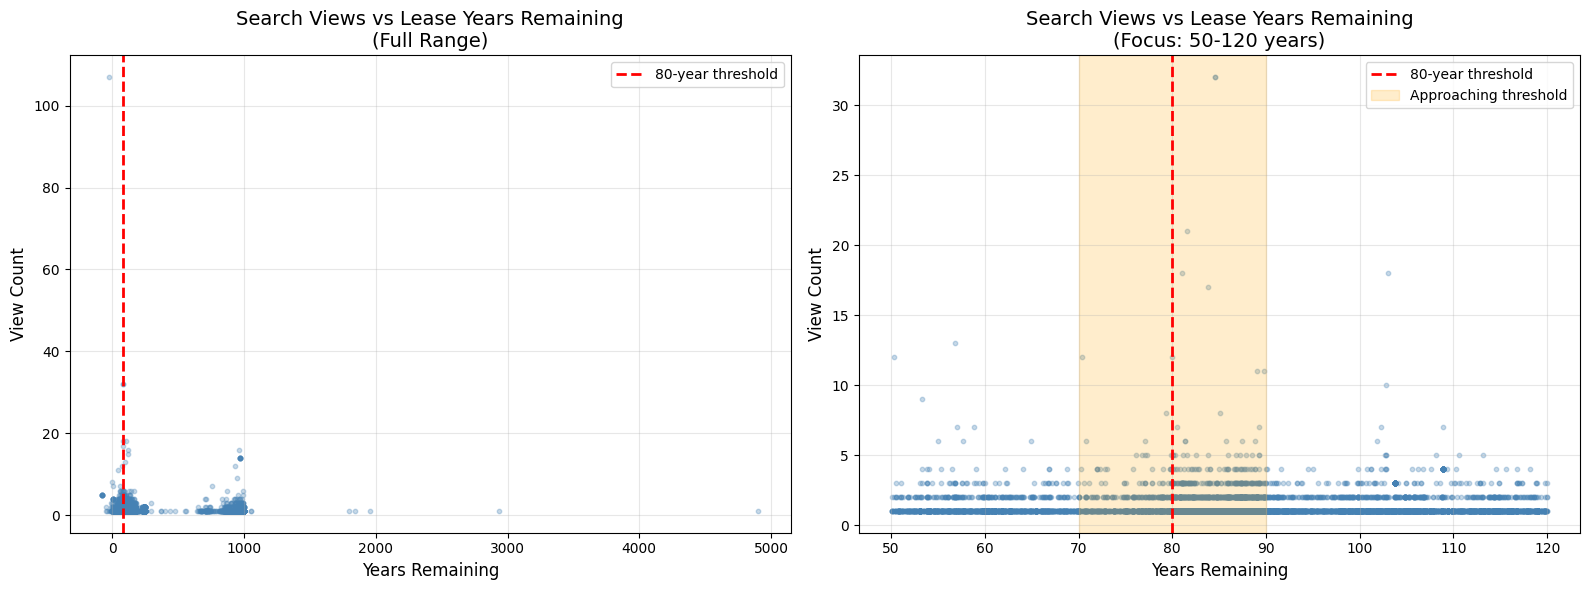

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Full range
ax1 = axes[0]
sample = df.sample(min(10000, len(df)), random_state=42)
ax1.scatter(sample['years_remaining'], sample['view_count'], alpha=0.3, s=10, c='steelblue')
ax1.axvline(x=80, color='red', linestyle='--', linewidth=2, label='80-year threshold')
ax1.set_xlabel('Years Remaining', fontsize=12)
ax1.set_ylabel('View Count', fontsize=12)
ax1.set_title('Search Views vs Lease Years Remaining\n(Full Range)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Focus on 50-120 years range
ax2 = axes[1]
df_focus = df[(df['years_remaining'] >= 50) & (df['years_remaining'] <= 120)]
sample_focus = df_focus.sample(min(10000, len(df_focus)), random_state=42)
ax2.scatter(sample_focus['years_remaining'], sample_focus['view_count'], alpha=0.3, s=10, c='steelblue')
ax2.axvline(x=80, color='red', linestyle='--', linewidth=2, label='80-year threshold')
ax2.axvspan(70, 90, alpha=0.2, color='orange', label='Approaching threshold')
ax2.set_xlabel('Years Remaining', fontsize=12)
ax2.set_ylabel('View Count', fontsize=12)
ax2.set_title('Search Views vs Lease Years Remaining\n(Focus: 50-120 years)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('correlation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Bar Chart

Mean View Count by Category

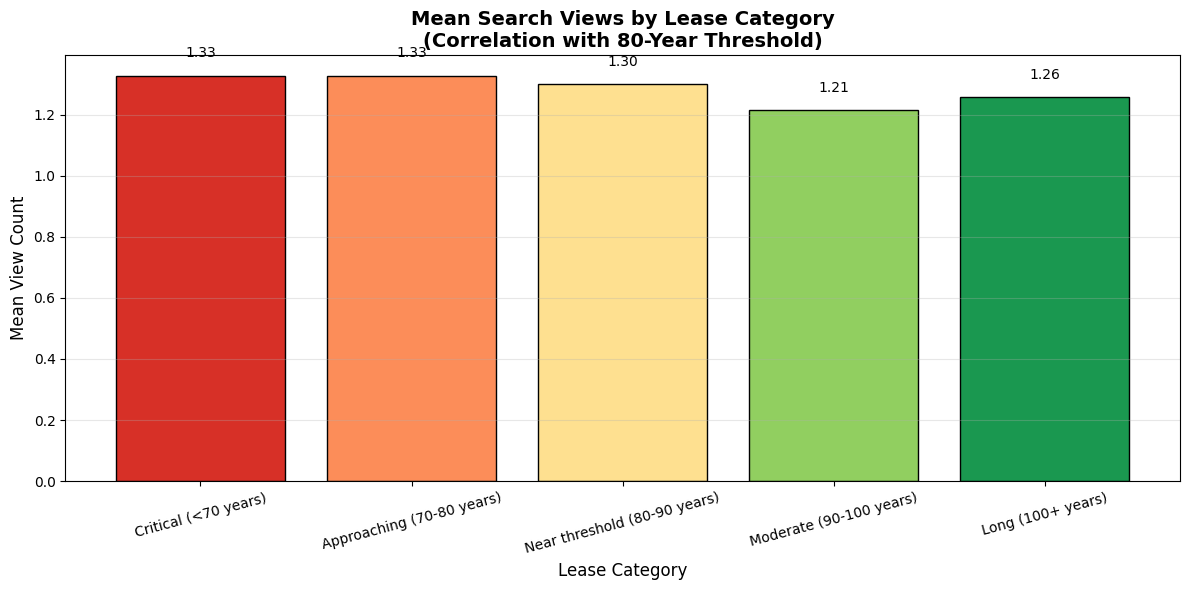

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

category_order = ['Critical (<70 years)', 'Approaching (70-80 years)', 
                  'Near threshold (80-90 years)', 'Moderate (90-100 years)', 'Long (100+ years)']

mean_views = df.groupby('category')['view_count'].mean().reindex(category_order)
colors = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']

bars = ax.bar(mean_views.index, mean_views.values, color=colors, edgecolor='black')

ax.set_xlabel('Lease Category', fontsize=12)
ax.set_ylabel('Mean View Count', fontsize=12)
ax.set_title('Mean Search Views by Lease Category\n(Correlation with 80-Year Threshold)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)

# Add value labels
for bar, val in zip(bars, mean_views.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
# plt.savefig('mean_views_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Sliding Window Analysis

Binned Analysis: Average Views by Year Bucket

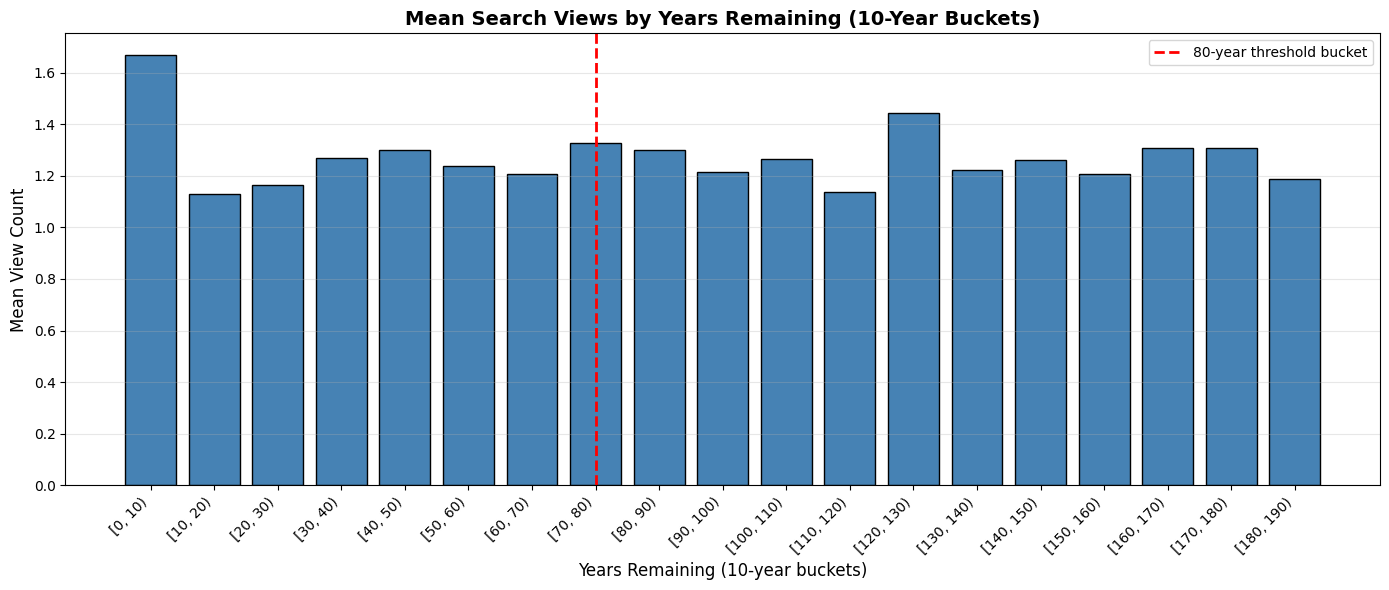

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create 10-year bins
df['year_bucket'] = pd.cut(df['years_remaining'], bins=range(0, 200, 10), right=False)
bucket_stats = df.groupby('year_bucket')['view_count'].agg(['mean', 'count']).reset_index()
bucket_stats['year_bucket_str'] = bucket_stats['year_bucket'].astype(str)

# Filter buckets with sufficient data
bucket_stats = bucket_stats[bucket_stats['count'] >= 10]

ax.bar(range(len(bucket_stats)), bucket_stats['mean'], color='steelblue', edgecolor='black')
ax.set_xticks(range(len(bucket_stats)))
ax.set_xticklabels(bucket_stats['year_bucket_str'], rotation=45, ha='right')
ax.axvline(x=list(bucket_stats['year_bucket_str']).index('[70, 80)') if '[70, 80)' in list(bucket_stats['year_bucket_str']) else -1, 
           color='red', linestyle='--', linewidth=2, label='80-year threshold bucket')

ax.set_xlabel('Years Remaining (10-year buckets)', fontsize=12)
ax.set_ylabel('Mean View Count', fontsize=12)
ax.set_title('Mean Search Views by Years Remaining (10-Year Buckets)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
# plt.savefig('views_by_year_bucket.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Cleanup

Close the MongoDB connection.

In [17]:
client.close()
print("MongoDB connection closed")

MongoDB connection closed
